In [1]:
import pandas as pd
import numpy as np
import preprocess

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Load raw data, split, build per-model pipelines

In [2]:
model_cfgs = {
    "LR": {
        "prep": "logistic_regression",
        "clf": LogisticRegression(solver='liblinear', random_state=42),
        "search_params": {'C': [0.1, 0.5, 1.0, 5, 10]}
    },
    "DT": {
        "prep": "decision_tree",
        "clf": DecisionTreeClassifier(random_state=42),
        "search_params": {'max_depth': [2, 3, 4, 5]}
    },
    "RF": {
        "prep": "random_forest",
        "clf": RandomForestClassifier(random_state=42),
        "search_params": {'max_depth': [2, 3, 4, 5], 'n_estimators': [25, 50, 75, 100]}
    },
    "KNN": {
        "prep": "knn",
        "clf": KNeighborsClassifier(n_neighbors=5),
        "search_params": {}  # Fix n_neighbors
    },
    "SVM": {
        "prep": "svm",
        "clf": SVC(probability=True, random_state=42, kernel='rbf'),
        "search_params": {
            'C': [0.1, 0.5, 1.0, 5, 10],
            'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
        }  # fix kernel
    }
}

In [3]:
raw = pd.read_csv("dataset/raw.csv")
X = raw.drop(columns=[preprocess.TARGET])
y = raw[preprocess.TARGET]

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"dev (train+val): {X_dev.shape}, test: {X_test.shape}")

dev (train+val): (242, 13), test: (61, 13)


## Train 5 classifier
- Hyper para search
- 5-fold CV
- Train
- test + collect ROC / Confusion Matrix data

In [4]:
from IPython.display import display

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

test_result = {}

print("================== Start training ===================")
for name, config in model_cfgs.items():
    print(f"\nTraining {name}")

    pipe = preprocess.build_pipeline(config["prep"], config["clf"])

    grid_params = {f"clf__{k}": v for k, v in config["search_params"].items()}
    grid = GridSearchCV(pipe, grid_params, cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_dev, y_dev)
    best_clf = grid.best_estimator_
    print(f"{name} best parameter setting: {grid.best_params_}")

    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv_results = cross_validate(best_clf, X_dev, y_dev, cv=cv, scoring=scoring, return_estimator=True)

    fold_val = cv_results['test_accuracy']
    fold_test = np.array([est.score(X_test, y_test) for est in cv_results['estimator']])
    fold_tbl = pd.DataFrame({
        "Fold": [str(i) for i in range(1, cv.get_n_splits() + 1)] + ["avg"],
        "Validation": list(np.round(fold_val, 4)) + [round(fold_val.mean(), 4)],
        "Test":       list(np.round(fold_test, 4)) + [round(fold_test.mean(), 4)],
    })
    display(fold_tbl)

    # Refit on the full train-validation pool, then evaluate on the separated test set.
    best_clf.fit(X_dev, y_dev)
    y_pred = best_clf.predict(X_test)
    y_probs = best_clf.predict_proba(X_test)[:, 1] if hasattr(best_clf, "predict_proba") else None

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    if y_probs is not None:
        metrics["auc"] = roc_auc_score(y_test, y_probs)

    test_result[name] = {
        "model": best_clf,
        "X_test": X_test,
        "y_test": y_test,
        "y_probs": y_probs,
        "cv_scores": cv_results,
        "fold_val": fold_val,
        "fold_test": fold_test,
        "val_accuracy": fold_val.mean(),
        "metrics": metrics,
    }
    print(f"Avg Validation (5-fold): {fold_val.mean():.4f} | Avg Test (5-fold): {fold_test.mean():.4f} | Final Test: {metrics['accuracy']:.4f}")
    print("-" * 50)

================== Start training ===================

Training LR
LR best parameter setting: {'clf__C': 0.1}


,Fold,Validation,Test
0,1,0.8163,0.9016
1,2,0.8571,0.9180
2,3,0.8542,0.9016
3,4,0.8542,0.8525
4,5,0.7917,0.9016
5,avg,0.8347,0.8951


Avg Validation (5-fold): 0.8347 | Avg Test (5-fold): 0.8951 | Final Test: 0.8852
--------------------------------------------------

Training DT
DT best parameter setting: {'clf__max_depth': 4}


,Fold,Validation,Test
0,1,0.7143,0.8033
1,2,0.8163,0.7705
2,3,0.7292,0.7869
3,4,0.7292,0.7213
4,5,0.7708,0.7705
5,avg,0.7520,0.7705


Avg Validation (5-fold): 0.7520 | Avg Test (5-fold): 0.7705 | Final Test: 0.7869
--------------------------------------------------

Training RF
RF best parameter setting: {'clf__max_depth': 2, 'clf__n_estimators': 25}


...

Avg Validation (5-fold): 0.8224 | Avg Test (5-fold): 0.8689 | Final Test: 0.8852
--------------------------------------------------

Training KNN
KNN best parameter setting: {}


,Fold,Validation,Test
0,1,0.8367,0.9180
1,2,0.8367,0.9344
2,3,0.8958,0.9016
3,4,0.7708,0.8689
4,5,0.8125,0.9180
5,avg,0.8305,0.9082


Avg Validation (5-fold): 0.8305 | Avg Test (5-fold): 0.9082 | Final Test: 0.9016
--------------------------------------------------

Training SVM
SVM best parameter setting: {'clf__C': 10, 'clf__gamma': 0.001}


,Fold,Validation,Test
0,1,0.8163,0.8525
1,2,0.8571,0.8689
2,3,0.8542,0.8852
3,4,0.8333,0.8689
4,5,0.7708,0.9016
5,avg,0.8264,0.8754


Avg Validation (5-fold): 0.8264 | Avg Test (5-fold): 0.8754 | Final Test: 0.9016
--------------------------------------------------


## Per-fold validation / test accuracy
Each model's 5-fold validation and test accuracy is shown per fold above; this is the summary across models.

In [5]:
#   Avg Val    = mean held-out CV-fold accuracy
#   Avg Test   = mean accuracy of the 5 fold-models on the separate test set
#   Final Test = single model refit on the full train set, scored once on test
summary = pd.DataFrame([
    {
        "Model": name,
        "Avg Val": round(np.mean(d["fold_val"]), 4),
        "Avg Test": round(np.mean(d["fold_test"]), 4),
        "Final Test": round(d["metrics"]["accuracy"], 4),
    }
    for name, d in test_result.items()
])
display(summary)

,Model,Avg Val,Avg Test,Final Test
0,LR,0.8347,0.8951,0.8852
1,DT,0.7520,0.7705,0.7869
2,RF,0.8224,0.8689,0.8852
3,KNN,0.8305,0.9082,0.9016
4,SVM,0.8264,0.8754,0.9016


## Plot Test Result
- Basic metrics
    - Acc
    - Precision
    - Recall
    - f1
    - AUC
- ROC curve
- Confusion Matrix
- 5-fold CV

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

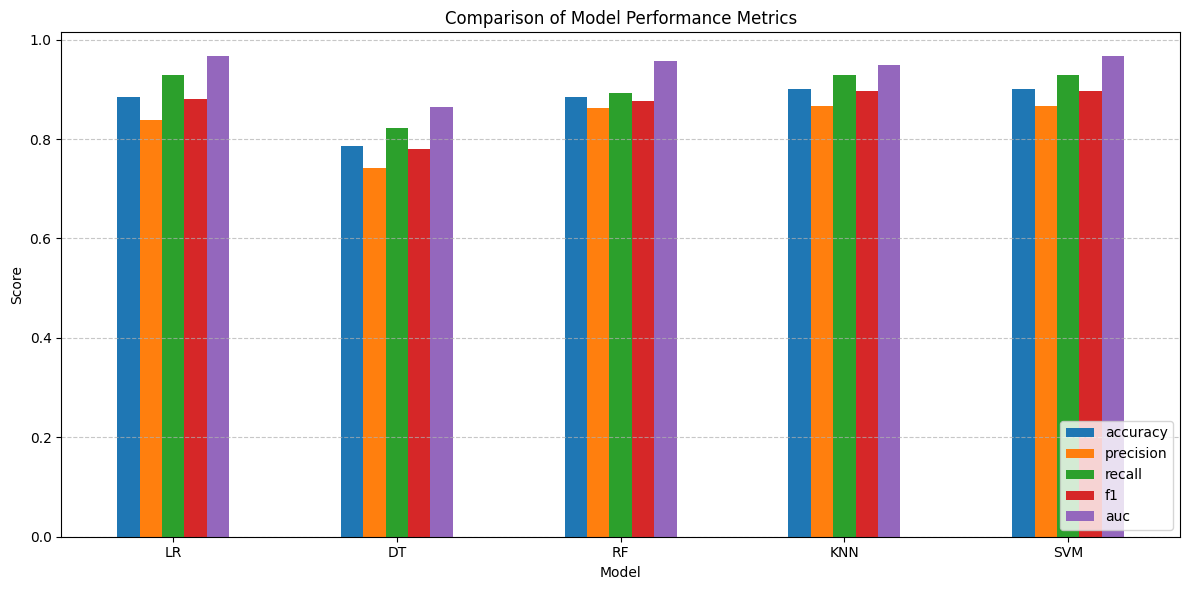

<Figure size 640x480 with 0 Axes>

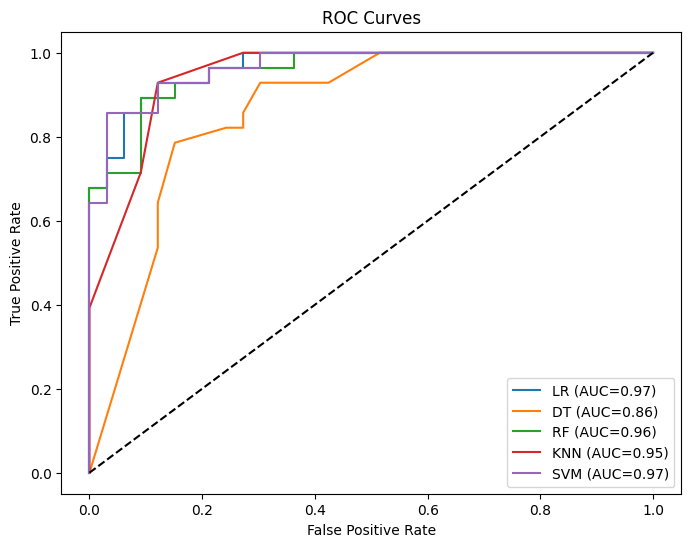

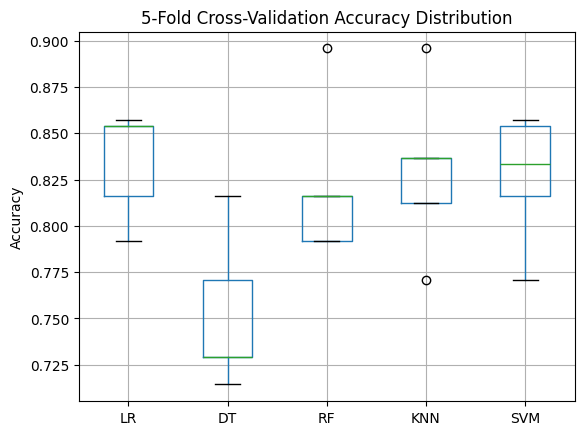

<Figure size 640x480 with 0 Axes>

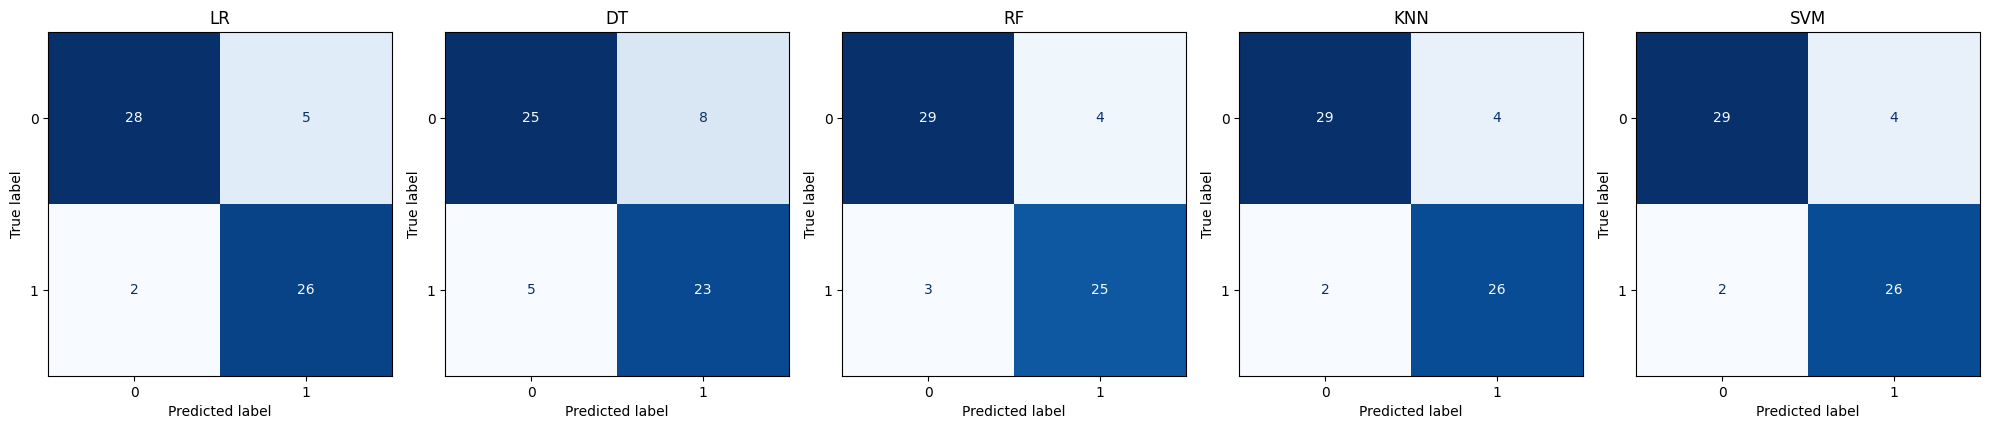

<Figure size 640x480 with 0 Axes>

In [7]:
def plot_project_visualizations(test_result):
    # 1. 準備綜合比較表格 (Metrics Comparison)
    metrics_list = []
    for name, data in test_result.items():
        row = data["metrics"].copy()
        row["Model"] = name
        metrics_list.append(row)
    df_metrics = pd.DataFrame(metrics_list).set_index("Model")

    # A. 繪製：各模型指標比較圖 (Bar Chart)
    df_metrics.plot(kind='bar', figsize=(12, 6), rot=0)
    plt.title("Comparison of Model Performance Metrics")
    plt.ylabel("Score")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    file_name = "./img/metrics.png"
    plt.savefig(file_name, dpi=300)


    # B. 繪製：合併 ROC 曲線圖
    plt.figure(figsize=(8, 6))
    for name, data in test_result.items():
        fpr, tpr, _ = roc_curve(data["y_test"], data["y_probs"])
        plt.plot(fpr, tpr, label=f"{name} (AUC={data['metrics']['auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()
    file_name = "./img/ROC.png"
    plt.savefig(file_name, dpi=300)

    # C. 繪製：5-Fold CV 盒鬚圖 (Box Plot) - 展現模型的穩定性
    cv_data = {name: data["cv_scores"]["test_accuracy"] for name, data in test_result.items()}
    pd.DataFrame(cv_data).boxplot(figsize=(10, 5))
    plt.title("5-Fold Cross-Validation Accuracy Distribution")
    plt.ylabel("Accuracy")
    plt.show()
    file_name = "./img/5_fold_CV.png"
    plt.savefig(file_name, dpi=300)

    # D. 繪製：混淆矩陣 (Confusion Matrices - 這裡我們用子圖畫成一排)
    fig, axes = plt.subplots(1, len(test_result), figsize=(20, 4))
    for i, (name, data) in enumerate(test_result.items()):
        ConfusionMatrixDisplay.from_estimator(
            data["model"], data["X_test"], data["y_test"], 
            ax=axes[i], cmap="Blues", colorbar=False
        )
        axes[i].set_title(name)
    plt.tight_layout()
    plt.show()
    file_name = "./img/confusion.png"
    plt.savefig(file_name, dpi=300)

plot_project_visualizations(test_result)